In [ ]:
import shap
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from src.core.config import MODEL_PATH,DATA_PROCESSED

c:\Users\USER\Desktop\Warfarin_IWPC_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = joblib.load(MODEL_PATH)
x_train_path= DATA_PROCESSED/"X_train.joblib"
x_test_path= DATA_PROCESSED/"X_test.joblib"
X_train = joblib.load(x_train_path)
X_test = joblib.load(x_test_path)

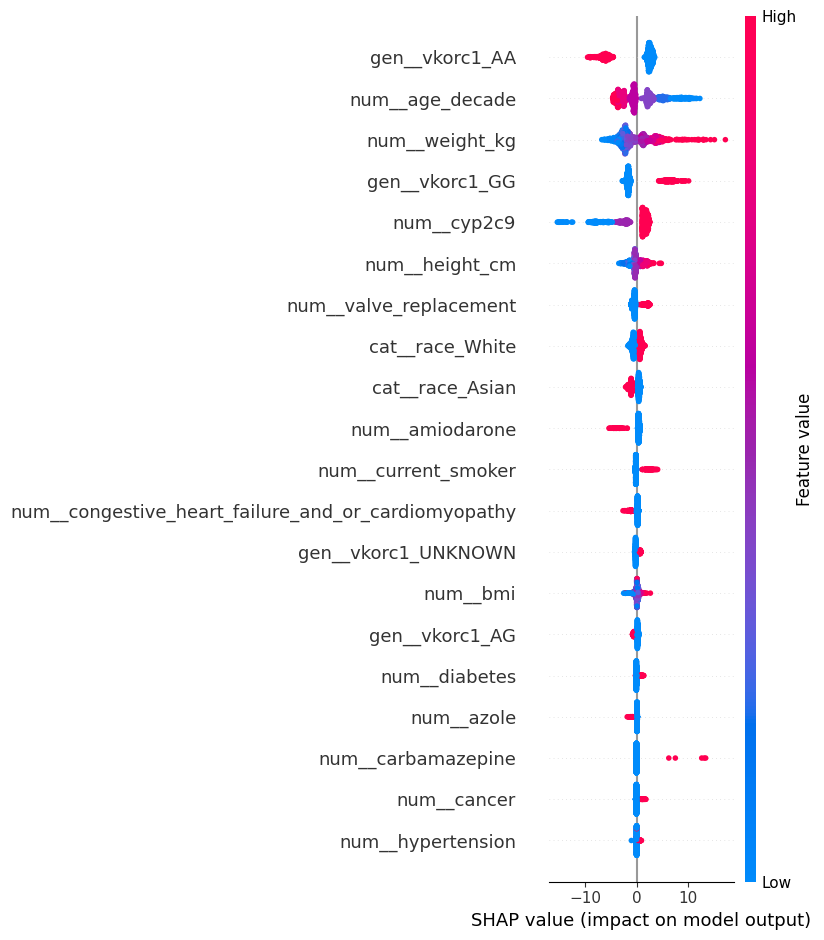

In [3]:

preprocessor = model.named_steps["preprocessor"]
xgb_model = model.named_steps["model"]


X_test=X_test.iloc[:1000]

X_test_transformed = preprocessor.transform(X_test)
X_test_transformed=X_test_transformed[:1000]
    
feature_names = preprocessor.get_feature_names_out()
 

explainer = shap.TreeExplainer(xgb_model,feature_perturbation="tree_path_dependent")

shap_values = explainer.shap_values(X_test_transformed)
X_plot=pd.DataFrame(X_test_transformed.toarray() if hasattr(X_test_transformed,"toarray") else X_test_transformed,columns=feature_names)
 
shap.summary_plot(
        shap_values,
        X_plot,
        max_display=20,
        show=False)

In [4]:
mean_absolute_shap=np.abs(shap_values).mean(axis=0)
global_importance=pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap' : mean_absolute_shap
}).sort_values('mean_abs_shap',ascending=False).head(20)
global_importance

,feature,mean_abs_shap
39,gen__vkorc1_AA,3.686770
11,num__age_decade,3.074266
1,num__weight_kg,2.782114
41,gen__vkorc1_GG,2.724026
13,num__cyp2c9,2.602443
0,num__height_cm,0.970057
4,num__valve_replacement,0.779634
35,cat__race_White,0.708701
32,cat__race_Asian,0.652513
14,num__amiodarone,0.574979


In [5]:
shap_df = pd.DataFrame(
    shap_values,
    columns=feature_names
)
shap_df

,num__height_cm,num__weight_kg,num__diabetes,num__congestive_heart_failure_and_or_cardiomyopathy,num__valve_replacement,num__aspirin,num__acetaminophen_or_paracetamol_tylenol,num__sulfonamide_antibiotics,num__macrolide_antibiotics,num__anti_fungal_azoles,...,cat__race_Black or African American,cat__race_Unknown,cat__race_White,cat__ethnicity_Hispanic or Latino,cat__ethnicity_Unknown,cat__ethnicity_not Hispanic or Latino,gen__vkorc1_AA,gen__vkorc1_AG,gen__vkorc1_GG,gen__vkorc1_UNKNOWN
0,2.068395,0.809845,-0.076813,0.143332,-0.379009,-0.234461,-0.030998,0.000043,-0.000069,0.001473,...,-0.000985,0.021787,0.354443,0.008046,0.011097,0.055819,2.030308,-0.657060,-1.820240,-0.213434
1,-0.597704,-3.796186,-0.120909,0.152166,1.155765,-0.095964,-0.036126,0.000036,-0.000069,0.001617,...,0.067023,-0.371494,-0.695675,0.001941,0.086819,0.035332,1.934289,0.155370,5.255432,-0.107952
2,0.981820,-0.616918,-0.075806,0.147927,-0.433642,0.029706,-0.038986,0.000008,-0.000069,0.001496,...,-0.019255,0.021225,0.640083,0.013385,0.014466,0.061543,2.482512,0.245469,-1.838100,0.287763
3,-0.516826,-2.468637,-0.155391,0.131290,-0.434511,0.010091,-0.061887,0.000043,-0.000069,0.000872,...,-0.037112,0.011750,0.296013,0.008915,-0.006214,0.053220,1.724802,0.196366,-1.536252,0.576776
4,1.640884,3.159302,0.027972,0.231798,-0.338061,0.047039,0.043019,0.000156,-0.000069,0.001379,...,0.037802,0.041182,1.530367,0.014028,0.015496,0.138128,3.263457,0.357903,7.465647,-0.067036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.867226,-1.766888,-0.120237,0.249013,-0.370716,0.011026,-0.011013,0.000086,-0.000069,0.000815,...,-0.013241,0.038147,0.469140,0.006879,1.161029,0.011137,2.128596,-0.660708,-1.812516,-0.298005
996,2.055310,0.060661,-0.110348,0.043103,-0.230438,0.027433,0.007367,0.000135,-0.000069,0.001602,...,0.042366,0.014823,0.492580,0.007544,0.187962,-0.114392,2.069770,0.354472,6.069640,-0.040338
997,-0.207233,1.107071,-0.090299,0.042814,-0.345571,-0.089311,0.018220,0.000121,-0.000069,0.001433,...,0.006737,0.018366,0.383131,0.008570,0.110837,-0.106996,2.172375,-0.612941,-1.455783,-0.306056
998,0.192848,7.751401,0.497993,0.092495,-0.317217,0.019855,-0.016530,0.000220,-0.000055,0.001835,...,-0.245777,0.041054,0.422590,0.008025,-0.340208,-0.461874,2.713750,-0.452210,-2.390112,-0.169730


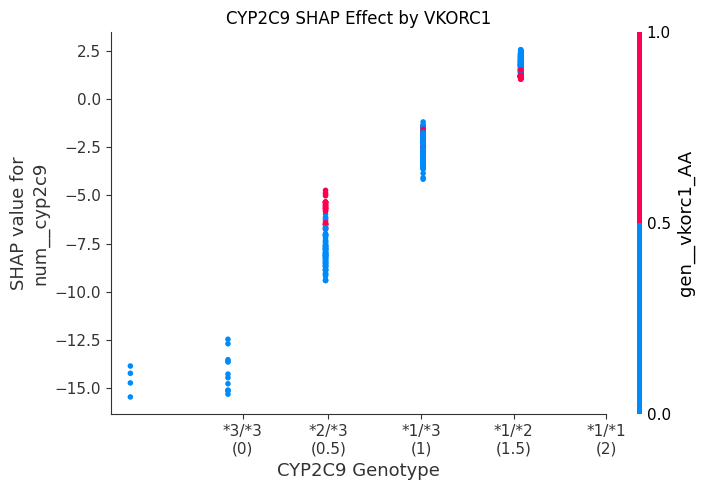

In [6]:

cyp2c9_col = [f for f in feature_names if 'cyp2c9' in f][0]
vkorc1_col = [f for f in feature_names if 'vkorc1' in f][0]

shap.dependence_plot(
    ind=cyp2c9_col,
    shap_values=shap_values, 
    features=X_plot,
    feature_names=feature_names,
    interaction_index=vkorc1_col, 
    show=False
)
plt.xticks([-3.4, -2.2, -0.9, 0.4, 1.7],
           ['*3/*3\n(0)', '*2/*3\n(0.5)', '*1/*3\n(1)', '*1/*2\n(1.5)', '*1/*1\n(2)'])
plt.xlabel("CYP2C9 Genotype")
plt.title("CYP2C9 SHAP Effect by VKORC1")
plt.tight_layout()
plt.savefig("cyp2c9_vs_vkorc1.png", dpi=300)
plt.show()


In [8]:
mask = (
    (X_test["vkorc1"] == "AA") &
    (X_test["cyp2c9"] == 0.0) )
cyp_col=[col for col in feature_names if "cyp2c9" in col]
vkorc1_col=[col for col in feature_names if "vkorc1" in col]
relevant_cols=cyp_col + vkorc1_col

interaction = shap_df.loc[mask,relevant_cols].sum(axis=1).mean()
interaction


nan

In [9]:
mask.sum()

np.int64(0)

In [10]:
mask_aa = X_test["vkorc1"] == "AA"
mask_ga = X_test["vkorc1"] == "AG"
mask_gg = X_test["vkorc1"] == "GG"

vkorc1_aa_col = [col for col in feature_names if "vkorc1" in col and "AA" in col][0]
vkorc1_ag_col = [col for col in feature_names if "vkorc1" in col and "AG" in col][0]
vkorc1_gg_col = [col for col in feature_names if "vkorc1" in col and "GG" in col][0]

print("VKORC1 AA:", shap_df.loc[mask_aa, vkorc1_aa_col].mean())
print("VKORC1 AG:", shap_df.loc[mask_ga, vkorc1_ag_col].mean())
print("VKORC1 GG:", shap_df.loc[mask_gg, vkorc1_gg_col].mean())

VKORC1 AA: -6.416551
VKORC1 AG: -0.5193133
VKORC1 GG: 6.376016


In [11]:
for genotype in sorted(X_test["cyp2c9"].unique()):
    mask = X_test["cyp2c9"] == genotype
    cyp2c9_col=[col for col in feature_names if "cyp2c9" in col]
    effect = shap_df.loc[mask, cyp2c9_col].values.mean()
    print(f"Genotype{genotype}: {effect:.6f}")

Genotype0.0: -14.555329
Genotype0.5: -14.165489
Genotype1.0: -7.363839
Genotype1.5: -2.416398
Genotype2.0: 1.651560


#cyp2c9 genotypes mapping:
   
     '*1/*1' : 2.0
     '*1/*2' : 1.5
     '*1/*3' : 1.0
     '*2/*2' : 1.0
     '*2/*3' : 0.5
     '*3/*3' : 0.0

In [12]:
mask = X_test["amiodarone"] == 1
amiodarone_col=[col for col in feature_names if "amiodarone" in col]
effect = shap_df.loc[mask, amiodarone_col].mean()

print("Amiodarone effect:", effect)

Amiodarone effect: num__amiodarone   -3.851017
dtype: float32


In [13]:
mask = (
    (X_test["vkorc1"] == "AA") &
    (X_test["amiodarone"] == 1) 
   
)
amiodarone_col=[col for col in feature_names if "amiodarone" in col]
vkorc1_col=[col for col in feature_names if "vkorc1" in col]
relevant_cols=amiodarone_col + vkorc1_col

interaction = shap_df.loc[mask,relevant_cols].sum(axis=1).mean()

print("AA + amiodarone total contribution:", interaction)

AA + amiodarone total contribution: -10.281667


- VKORC1 AA significantly reduces dose → increased sensitivity
- CYP2C9 variants reduce metabolism → lower dose required
- Amiodarone further decreases dose via drug interaction

Clinical validation:
- Matches pharmacogenetic expectations (CPIC guidelines)
- Model captures biologically meaningful relationships

Conclusion:
Model is interpretable and clinically consistent